In [19]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import ast
import re
import seaborn as sns

In [20]:
def merge_cleaned_datasets(flat_path, house_path, indepedent_builder_floor_path, shuffle=True):
        
        
        flats_df = pd.read_csv(flat_path)
        houses_df = pd.read_csv(house_path)
        indepedent_builder_floor_df = pd.read_csv(indepedent_builder_floor_path)



        flats_df["property_type"] = "Flat"
        houses_df["property_type"] = "Independent House"
        indepedent_builder_floor_df["property_type"] = "Independent Builder Floor"


        merged_df = pd.concat([flats_df, houses_df, indepedent_builder_floor_df], ignore_index=True, sort=False)

        if shuffle:
            merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

        return merged_df

In [21]:
merged_df = merge_cleaned_datasets(
    r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\data_cleaning\cleaned_residential_apartment.csv",
    r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\data_cleaning\cleaned_independent_houses.csv",
    r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\data_cleaning\cleaned_independent_builder_floor.csv"
)

In [22]:
merged_df.shape

(5974, 18)

In [23]:
merged_df.sample(30)

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type
2730,"9 Bedroom House in Sector 45, Gurgaon","Sector 45, Gurgaon",7.35,40033,1836 sqft (170.57 sqm) Plot Area,U84829842,https://www.99acres.com/9-bhk-bedroom-independ...,9,9,2,pooja room,3 Floors,south-east,10+ Year Old,"['12 Fan', '1 Exhaust Fan', '1 Microwave', '32...","['Water Storage', 'Recently Renovated', 'Natur...","['Icici ATM', 'Shivam Hospital Gurgaon', 'Hdfc...",Independent House
3916,"3 BHK Flat in Sector 66, Gurgaon",emaar mgf the palm drive,4.45,22820,"1,950 sqft (181 sqm) Super Built-up Area",G85369898,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,2,servant room,3rd of 17 Floors,east,5 to 10 Year Old,"['5 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stov...","['Centrally Air Conditioned', 'Water purifier'...","['HUB 66', 'Ashoka International School', 'Vat...",Flat
123,"4 Bedroom House in Nirvana Country, Gurgaon",Unitech Espace,12.90,39815,3240 sqft (301.01 sqm) Plot Area,I79187863,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3,"study room,servant room",3 Floors,east,10+ Year Old,"['4 Wardrobe', '8 Fan', '1 Exhaust Fan', '7 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House
763,"3 BHK Flat in Sector 104, Gurgaon",hero homes,2.50,23101,"1,689 sqft (157 sqm) Super Built-up Area",P81707850,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,3,pooja room,21st of 35 Floors,north-east,1 to 5 Year Old,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['SGT University', 'Medanta Hospital', 'Taj Ci...",Flat
2030,1 Bedroom House in Ashok Vihar Phase 3 Extensi...,"Ashok Vihar Phase 3 Extension, Gurgaon",1.10,12222,900 sqft (83.61 sqm) Built-up Area,X82066648,https://www.99acres.com/1-bhk-bedroom-independ...,1,1,0,not available,1 Floors,not available,NaN,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,"['Prateek Nursing Home And Polyclinic', 'R K H...",Independent House
5765,"3 Bedroom House in Sector 26, Gurgaon",DLF City Phase 1,5.50,40741,1350 sqft (125.42 sqm) Plot Area,R77280511,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,not available,2 Floors,not available,10+ Year Old,"['3 Wardrobe', '2 Geyser', '12 Light', 'No AC'...","['Feng Shui / Vaastu Compliant', 'Maintenance ...","['Gurgaon', 'Appu Ghar', 'IILM University', 'D...",Independent House
547,"10 Bedroom House in Sector 39, Gurgaon","Sector 39, Gurgaon",7.00,29573,2367 sqft (219.9 sqm) Plot Area,D84756260,https://www.99acres.com/10-bhk-bedroom-indepen...,10,10,2,pooja room,3 Floors,south-east,10+ Year Old,"['14 Fan', '24 Light', 'No AC', 'No Bed', 'No ...","['Water Storage', 'Recently Renovated', 'Natur...","['Icici ATM', 'Shivam Hospital Gurgaon', 'Hdfc...",Independent House
5821,"3 BHK Flat in Sector 67A, Gurgaon",ireo the corridors,3.10,27205,"1,839 sqft (171 sqm) Super Built-up Area",G84205348,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,3+,not available,11st of 19 Floors,north-east,1 to 5 Year Old,"['3 Wardrobe', '1 Water Purifier', '6 Fan', '1...","['Centrally Air Conditioned', 'Water purifier'...","['PVR Drive in Theatre', 'De Adventure Park', ...",Flat
5204,"3 Bedroom House in Baldev Nagar, Gurgaon","Baldev Nagar, Gurgaon",1.50,8333,1800 sqft (167.23 sqm) Plot Area | 1350 sqft (...,H82109204,https://www.99acres.com/3-bhk-bedroom-independ...,3,3,0,not available,2 Floors,not available,NaN,NaN,NaN,[],Independent House
2683,"2 BHK Flat in Sector 62, Gurgaon",emaar digihomes,3.60,23872,"1,508 sqft (140 sqm) Super Built-up Area",Z80714015,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,2,1,not available,16th of 32 Floors,west,1 to 5 Year Old,"['3 Fan', '1 Exhaust Fan', '2 Geyser', '6 Ligh...","['Centrally Air Conditioned', 'Security / Fire...","['De Adventure Park', 'AIPL Business Club', 'G...",Flat


In [24]:
merged_df.isnull().sum()

property_name           0
society                 0
price_in_cr             0
price_per_sqft          0
areawithtype            0
property_id             0
link                    0
bedrooms                0
bathrooms               0
balcony                 0
additional_room         0
floor_info            104
facing                  0
property_age          110
furnishing_details    822
features              376
nearby_location         0
property_type           0
dtype: int64

In [25]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_name       5974 non-null   object 
 1   society             5974 non-null   object 
 2   price_in_cr         5974 non-null   float64
 3   price_per_sqft      5974 non-null   int64  
 4   areawithtype        5974 non-null   object 
 5   property_id         5974 non-null   object 
 6   link                5974 non-null   object 
 7   bedrooms            5974 non-null   int64  
 8   bathrooms           5974 non-null   int64  
 9   balcony             5974 non-null   object 
 10  additional_room     5974 non-null   object 
 11  floor_info          5870 non-null   object 
 12  facing              5974 non-null   object 
 13  property_age        5864 non-null   object 
 14  furnishing_details  5152 non-null   object 
 15  features            5598 non-null   object 
 16  nearby

In [26]:
merged_df.duplicated().sum()

0

#### 1. Feature Engineering

In [27]:
merged_df_copy = merged_df.copy()

In [28]:
merged_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,"servant room,others",1st of 4 Floors,south-east,0 to 1 Year Old,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","['Feng Shui / Vaastu Compliant', 'Water purifi...","['Kotak mahindra bank ATM', 'CCD', 'Belgian Wa...",Independent Builder Floor
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,not available,2 Floors,not available,NaN,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,servant room,2 Floors,east,1 to 5 Year Old,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","['Water purifier', 'Centrally Air Conditioned'...","['Omaxe City Centre', 'Radisson Hotel Gurugram...",Independent House
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,not available,5th of 14 Floors,not available,10+ Year Old,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['DLF Golf and Country Club', ""Oyster's Water ...",Flat
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,not available,1 Floors,north-west,1 to 5 Year Old,NaN,['Water Storage'],"['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,pooja room,3 Floors,north-east,10+ Year Old,"['9 Fan', '1 Exhaust Fan', '1 Microwave', '24 ...","['Water Storage', 'Recently Renovated', 'Natur...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,"pooja room,store room,study room,servant room",1st of 4 Floors,north,1 to 5 Year Old,"['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Kotak mahindra bank ATM', 'Religare Wellness...",Independent Builder Floor
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,"study room,others,pooja room,servant room",3rd of 4 Floors,north-east,0 to 1 Year Old,"['7 Wardrobe', '7 Fan', '1 Exhaust Fan', '7 Ge...","['Water purifier', 'Centrally Air Conditioned'...",[],Independent Builder Floor
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,"pooja room,servant room,others",2nd of 4 Floors,east,1 to 5 Year Old,"['6 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stov...","['Water purifier', 'Centrally Air Conditioned'...","['Max, Fortis', 'Pathways', 'Golf Course Road'...",Independent Builder Floor


#### 1. Sector

In [29]:
fe_df =(merged_df.assign(
            sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()  
))

In [30]:
fe_df['sector'].value_counts()

sector
palam vihar               182
sector 102                180
sector 65                 175
sector 81                 162
dlf phase 1               153
                         ... 
huda sector                 1
block b sheetla colony      1
block c sector 17           1
sahib kunj                  1
block a surya vihar         1
Name: count, Length: 350, dtype: int64

In [31]:
fe_df =(merged_df
    .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
            )
)

In [32]:
fe_df['sector'].unique().tolist()

['sushant lok phase 1',
 'sohna road',
 'sector 72',
 'dlf phase 4',
 'behrampur',
 'sector 102',
 'sector33 sohna',
 'sector 45',
 'sector 90',
 'sohna',
 'malibu town',
 'sector 4',
 'sector 46',
 'south city 1',
 'sector 37d',
 'a block sushant lok phase 1',
 'sector 43',
 'dlf phase 2',
 'sector 67',
 'block q south city 1',
 'dlf phase 1',
 'sector 65',
 'sector 52',
 'sector 106',
 'sector 10a',
 'sector 89',
 'sector 54',
 'sector 23',
 'sector 104',
 'block g rajendra park',
 'sector 49',
 'sector 108',
 'block a greenwood city',
 'sector 81',
 'sushant lok 2sector 55',
 'sector 85',
 'sector 10',
 'sector 56',
 'block c2 sector 3',
 'sector 77',
 'patel nagar',
 'sushant lok phase 2',
 'sector 70a',
 'sector 7',
 'sector 89 a',
 'sector 82',
 'sector35 sohna',
 'block d rajendra park',
 'sector 91',
 'new palam vihar',
 'saraswati vihar',
 'sector 57',
 'sector 83',
 'sector 41',
 'sector 48',
 'sector 112',
 'palam vihar',
 'sector 28',
 'sector 67a',
 'sector 86',
 'sector 9

In [33]:
fe_df['sector'].nunique()

350

In [34]:
fe_df['sector'].value_counts().reset_index()

,sector,count
0,palam vihar,182
1,sector 102,180
2,sector 65,175
3,sector 81,162
4,dlf phase 1,153
...,...,...
345,huda sector,1
346,block b sheetla colony,1
347,block c sector 17,1
348,sahib kunj,1


Palam Vihar - Old Gurgaon - Sector 1, Sector 2, New Palam Vihar, Palam Vihar Extension - https://www.99acres.com/palam-vihar-gurgaon-overview-piffid

In [35]:
fe_df[fe_df['sector']=='hous']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
1842,"3 Bedroom House in Housing board colony,Sector...","Housing board colony,Sector 7 Ext, Gurgaon",0.75,7788,963 sqft (89.47 sqm) Plot Area,J84039884,https://www.99acres.com/3-bhk-bedroom-independ...,3,3,2,not available,2 Floors,not available,10+ Year Old,[],NaN,"['Kr Dental Hub', 'Pasricha Hospital and Mater...",Independent House,hous
1885,"4 Bedroom House in Housing board colony,Sector...","Housing board colony,Sector 7 Ext, Gurgaon",0.80,22222,360 sqft (33.45 sqm) Plot Area,M81914122,https://www.99acres.com/4-bhk-bedroom-independ...,4,2,3,"pooja room,study room",3 Floors,north-east,10+ Year Old,NaN,"['Feng Shui / Vaastu Compliant', 'Private Gard...","['Kr Dental Hub', 'Pasricha Hospital and Mater...",Independent House,hous
3122,"6 Bedroom House in Housing board colony,Sector...","Housing board colony,Sector 7 Ext, Gurgaon",0.65,18056,360 sqft (33.45 sqm) Plot Area,Y81786394,https://www.99acres.com/6-bhk-bedroom-independ...,6,3,3,study room,4 Floors,north-east,10+ Year Old,"['6 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Kr Dental Hub', 'Pasricha Hospital and Mater...",Independent House,hous


In [36]:
fe_df[fe_df['sector']=='medicity']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
2697,"4 Bedroom House in Medicity, Gurgaon","Medicity, Gurgaon",9.0,61350,1467 sqft (136.29 sqm) Plot Area,P82891986,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,others,13 Floors,north-east,1 to 5 Year Old,"['1 Wardrobe', '2 Fan', '1 Light', 'No AC', 'N...",['Maintenance Staff'],"['Wellness Eye Centre', 'Bar and restaurant', ...",Independent House,medicity


In [37]:
fe_df[fe_df['sector']=='pataudi']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
3340,"5 Bedroom House in Pataudi, Gurgaon","Pataudi, Gurgaon",3.20,17778,1800 sqft (167.23 sqm) Plot Area,R84748786,https://www.99acres.com/5-bhk-bedroom-independ...,5,4,2,"pooja room,study room,servant room,store room",2 Floors,north,1 to 5 Year Old,"['4 Bed', '3 Wardrobe', '3 Fan', '7 Light', '2...","['High Ceiling Height', 'Maintenance Staff', '...","['Shree Kailash Hospital', 'Dr. Chauhan Neeraj...",Independent House,pataudi
4532,"3 Bedroom House in Pataudi, Gurgaon","Pataudi, Gurgaon",0.25,25000,80 sqft (7.43 sqm) Plot Area,I84416748,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,not available,NaN,not available,10+ Year Old,NaN,NaN,"['Dr. Kishore Rao Bhawan', 'Varma Dental and E...",Independent House,pataudi


In [38]:
fe_df[fe_df['sector']=='huda sector']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
2053,"7 Bedroom House in Huda Sector, Gurgaon","Huda Sector, Gurgaon",10.0,35727,2799 sqft (260.04 sqm) Plot Area,H84345526,https://www.99acres.com/7-bhk-bedroom-independ...,7,8,3+,"pooja room,servant room,study room",3 Floors,north,5 to 10 Year Old,"['1 Water Purifier', '11 Fan', '1 Fridge', '1 ...","['Water purifier', 'Centrally Air Conditioned'...","['Indusind bank ATM', 'Hong Kong Bazaar Mall',...",Independent House,huda sector


In [39]:
fe_df[fe_df['sector']=='ansal']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
1275,"5 Bedroom House in Ansal, Gurgaon","Ansal Sec-49,Gurgaon(Haryana)",15.5,41891,3700 sqft (343.74 sqm) Plot Area | 4725 sqft (...,W81122921,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,1,"servant room,pooja room,store room",1 Floors,north-east,5 to 10 Year Old,"['5 Fan', '1 Geyser', '6 Light', '1 AC', '1 TV...","['Feng Shui / Vaastu Compliant', 'Private Gard...",[],Independent House,ansal


In [40]:
fe_df[fe_df['sector']=='village']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
936,"3 Bedroom House in Gurgaon Village, Gurgaon","Gurgaon Village, Gurgaon",0.5,29412,170 sqft (15.79 sqm) Built-up Area,C81942078,https://www.99acres.com/3-bhk-bedroom-independ...,3,1,0,not available,1 Floors,not available,NaN,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House,village


In [41]:
fe_df[fe_df['sector']=='new']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
1200,2 Bedroom House in New Gurgaon,"New, Gurgaon",2.2,29411,748 sqft (69.49 sqm) Plot Area,P83277382,https://www.99acres.com/2-bhk-bedroom-independ...,2,1,2,not available,2 Floors,not available,10+ Year Old,[],NaN,"['Shri Balaji Hospital and Trauma Center', 'Ha...",Independent House,new
4772,4 Bedroom House in New Gurgaon,"New, Gurgaon",3.0,20000,1500 sqft (139.35 sqm) Plot Area,S81978402,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,not available,2 Floors,not available,1 to 5 Year Old,[],NaN,"['Petrol Pump IBP', 'Boxer Fuel Point', 'Haldi...",Independent House,new


In [42]:
sector_mapping = {
    # Blocks and Colonies mapped to specific Sectors for Geo-Mapping
    'nirvana country': 'sector 50',
    'palam vihar': 'sector 1',
    'dlf phase 1': 'sector 26',
    'dlf phase 2': 'sector 25',
    'sector 67a': 'sector 67',
    'sushant lok phase 1': 'sector 43',
    'sector 70a': 'sector 70',
    'sohna': 'sector 33',
    'dlf phase 4': 'sector 28',
    'block c sushant lok phase 1': 'sector 43',
    'sector33 sohna': 'sector 33',
    'malibu town': 'sector 47',
    'south city 2': 'sector 49',
    'south city 1': 'sector 41',
    'sector 37d': 'sector 37',
    'sushant lok phase 3': 'sector 57',
    'dlf phase 3': 'sector 24',
    'sector 110 a': 'sector 110',
    'a block sushant lok phase 1': 'sector 43',
    'rajendra park': 'sector 105',
    'b block sushant lok phase 1': 'sector 43',
    'dlf phase 5': 'sector 43',
    'greenwood city': 'sector 45',
    'sector 37c': 'sector 37',
    'sushant lok 3 extension': 'sector 57',
    'blocka dlf city phase 1': 'sector 26',
    'krishna colony': 'sector 7',
    'uppals southend': 'sector 49',
    'suncity': 'sector 54',
    'maruti kunj': 'sector 105',
    'rosewood city': 'sector 49',
    'ardee city': 'sector 52',
    'vishnu garden': 'sector 105',
    'sector 9a': 'sector 9',
    'sushant lok phase 2': 'sector 55',
    'g block dlf city phase 1': 'sector 26',
    'laxman vihar phase 2': 'sector 3',
    'urban estate': 'sector 4',
    'sushant lok 2sector 55': 'sector 55',
    'gwal pahari': 'gwal pahari',
    'sector 10a': 'sector 10',
    'block m dlf phase 2': 'sector 25',
    'patel nagar': 'sector 15',
    'new colony': 'sector 7',
    'v block dlf phase 3': 'sector 24',
    'pocket h nirvana country': 'sector 50',
    'sector 89 a': 'sector 89',
    'surat nagar phase 1': 'sector 104',
    'block b sushant lok 3': 'sector 57',
    'mayfield garden': 'sector 51',
    'saraswati enclave': 'sector 37',
    'block e dlf city phase 1': 'sector 26',
    'sector 15 part 2': 'sector 15',
    'sector 7 extension': 'sector 7',
    'jyoti park': 'sector 7',
    'dlf cyber city': 'sector 24',
    'block a south city 2': 'sector 49',
    'block n mayfield garden': 'sector 51',
    'block m south city 1': 'sector 41',
    'mg road': 'sector 28',
    'block c ardee city': 'sector 52',
    'block c2 sector 3': 'sector 3',
    'shivpuri': 'sector 7',
    'new palam vihar': 'sector 110',
    'c block mayfield garden': 'sector 50',
    'u block dlf phase 3': 'sector 24',
    'galleria market': 'sector 28',
    'block c sushant lok phase 3': 'sector 57',
    'block g sector57': 'sector 57',
    'c block sector 43': 'sector 43',
    'laxman vihar': 'sector 4',
    'block q south city 1': 'sector 41',
    'sohna road': 'sector 48',
    'garhi harsaru': 'sector 92',
    'bhondsi': 'bhondsi',
    'shivaji nagar': 'sector 11',
    'sector7 ext': 'sector 7',
    'block g rajendra park': 'sector 105',
    'arjun nagar': 'sector 8',
    'sector 88a': 'sector 88',
    'sector 36a': 'sector 36',
    'block j pocket c palam vihar': 'sector 1',
    'jacobpura': 'sector 12',
    'farukhnagar': 'farukhnagar',
    'b block pocket b palam vihar': 'sector 1',
    'sector 95a': 'sector 95',
    'sector 17b': 'sector 17',
    'sector 15 part 1': 'sector 15',
    'baldev nagar': 'sector 7',
    'block p south city 1': 'sector 41',
    'manesar': 'sector 1',
    'imt manesar': 'sector 1',
    'imt manesar':'sector 1',
    'sector 1 imt manesar': 'sector 1',
    'sector 1a imt manesar': 'sector 1',
    'pataudi': 'sector 1',
    'pataudi road': 'sector 1',
    'pataudi road':'sector 1',
    'block s uppals southend': 'sector 49',
    'block b rajendra park': 'sector 105',
    'sector 99a': 'sector 99',
    'sector 23a': 'sector 23',
    't block dlf phase 3': 'sector 24',
    's block dlf phase 3': 'sector 24',
    'ashok vihar phase 1': 'sector 5',
    'block k1 new palam vihar phase 1': 'sector 110',
    'b1 block sector 57': 'sector 57',
    'pocket e sector 2 palam vihar': 'sector 2',
    'saraswati vihar': 'sector 28',
    'block b palam vihar': 'sector 1',
    'dayanand colony': 'sector 6',
    'block n south city 1': 'sector 41',
    'block c palam vihar': 'sector 1',
    'b block mayfield garden': 'sector 50',
    'block d sector 56': 'sector 56',
    'old dlf colony': 'sector 14',
    'sushant lok': 'sector 43',
    'block e greenwood city': 'sector 46',
    'surat nagar phase 2': 'sector 104',
    'block a greenwood city': 'sector 45',
    'madanpuri': 'sector 7',
    'block d rajendra park': 'sector 105',
    'block c 1 palam vihar': 'sector 1',
    'om nagar': 'sector 11',
    'ashok vihar phase 3 extension': 'sector 3',
    'pocket i nirvana country': 'sector 50',
    'subhash nagar': 'sector 12',
    'pratap nagar': 'sector 8',
    'south city': 'sector 49',
    'rajiv nagar': 'sector 13',
    'chakkarpur': 'sector 28',
    'huda': 'sector 14',
    'hous': 'sector 7',
    'block b sector 56': 'sector 56',
    'block i south city 1': 'sector 41',
    'sector35 sohna': 'sector 35',
    'golf course ext road': 'sector 61',
    'block h dlf city phase 1': 'sector 26',
    'devilal colony': 'sector 9',
    'sector2 sohna': 'sector 2',
    'block e sector 56': 'sector 56',
    'sector22a': 'sector 22',
    'jhajjar road': 'sector 15',
    'block n new palam vihar phase 1': 'sector 110',
    'dhankot': 'sector 102',
    'mohyal colony': 'sector 40',
    'block c sheetla colony': 'sector 5',
    'shivji park colony': 'sector 10',
    'block j ashok vihar phase 3 extension': 'sector 3',
    'block k south city 1': 'sector 41',
    'manohar nagar': 'sector 8',
    'garden estate': 'sector 24',
    'block c greenwood city': 'sector 45',
    'g block sushant lok 3': 'sector 57',
    'block f sushant lok phase iii': 'sector 57',
    'sihi village': 'sector 84',
    'phase 3 sector 22a': 'sector 22',
    'block f new palam vihar phase 1': 'sector 110',
    'rattan garden': 'sector 7',
    'sector 21 pocket a': 'sector 21',
    'civil l': 'sector 15',
    'ambedkar nagar': 'sector 9',
    'om vihar': 'sector 23',
    'model town': 'sector 11',
    'feroz gandhi colony': 'sector 9',
    'rajiv chowk': 'sector 15',
    'sheetla colony': 'sector 5',
    'block a new palam vihar phase 2': 'sector 110',
    'part 3 sector 5': 'sector 5',
    'block f sector 57': 'sector 57',
    'sector 36 sohna': 'sector 36',
    'supermart1': 'sector 28',
    'new palam vihar phase 2': 'sector 110',
    'dlf golf course': 'sector 42',
    'block t sector109': 'sector 109',
    'heritage city': 'sector 25',
    'new amanpura': 'sector 6',
    'ashok vihar': 'sector 3',
    'village': 'sector 6',
    'alipur': 'sector 105',
    'acharya puri extension': 'sector 7',
    'sector 48 49 gurugram': 'sector 48',
    'block q dlf city phase2': 'sector 25',
    'dlf city': 'sector 26',
    'kirti nagar': 'sector 15',
    'pocket j palam vihar': 'sector 1',
    'shyam kunj': 'sector 105',
    'khandsha': 'sector 37',
    'surya vihar': 'sector 21',
    'begampur khatola': 'sector 74',
    'surat nagar': 'sector 104',
    'h block sector 82': 'sector 82',
    'dwarka expressway': 'sector 109',
    'trimurti villas': 'sector 11',
    'behrampur': 'sector 71',
    'block e sheetla colony': 'sector 5',
    'carterpuri village': 'sector 23',
    'block a surya vihar': 'sector 9',
    'bhawani enclave': 'sector 9',
    'sector 5 imt manesar': 'sector 5',
    'sahib kunj': 'sector 110',
    'sadar bazar': 'sector 12',
    'shankar vihar': 'sector 104',
    'block t new palam vihar phase 2': 'sector 110',
    'ashok vihar phase 2': 'sector 5',
    'jakhopur': 'sector 6',
    'kanahi': 'sector 44',
    'islampur colony': 'sector 38',
    'new basti': 'sector 8',
    'huda sector': 'sector 55',
    'sector 2 palam vihar': 'sector 2',
    'basai village': 'sector 101',
    'baharampur naya': 'sector 61',
    'block e dharam colony': 'sector 10',
    'friends colony': 'sector 15',
    'palam vihar extension': 'sector 110',
    'islampur village': 'sector 38',
    'near medanta hospital': 'sector 38',
    'block m new palam vihar phase 1': 'sector 110',
    'sector 3a': 'sector 3',
    'sanjay colony': 'sector 6',
    'adarsh nagar': 'sector 12',
    'rajiv colony': 'sector 33',
    'shanti kunj': 'sector 110',
    'mianwali colony': 'sector 12',
    'block d sector 50': 'sector 50',
    'vatika kunj extension': 'sector 105',
    'railyway road gurgaon': 'sector 11',
    'sai kunj block c': 'sector 110',
    'block c harijan basti': 'sector 17',
    'block d greenwood city': 'sector 46',
    's block garden estate': 'sector 24',
    'block c sector 17': 'sector 17',
    'jharsa': 'sector 39',
    'laxmi garden': 'sector 11',
    'west rajiv nagar': 'sector 12',
    'ansal': 'sector 49',
    'block b sheetla colony': 'sector 5',
    'c block sector50': 'sector 50',
    'sector 72a': 'sector 72',
    'jawahar nagar': 'sector 12',
    'medicity': 'sector 38',
    'kadipur industrial area': 'sector 31',
    'sector 22b': 'sector 22',
    'a block sushant lok phase 3': 'sector 43',
    'jail road': 'sector 55',
    'block c dlf phase 1': 'sector 26',
    'hasanpur': 'sector 105',
    'sarhaul abadi village': 'sector 18',
    'dhumaspur': 'sector 68',
    'shanti nagar': 'sector 11',
    'laxman vihar industrial area': 'sector 3',
    'vijay park': 'sector 8',
    'uday nagar': 'sector 45',
    'heera nagar': 'sector 11',
    'block h south city 2': 'sector 70',
    'new palam vihar phase 3': 'sector 110',
    'block h sector57': 'sector 57',
    'gandhi nagar': 'sector 28',
    'kadipur': 'sector 10',
    'nihali colony': 'sector 110',
    'gurgaon sector 12': 'sector 12',
    'sector 63a': 'sector 63',
    'sector 82a': 'sector 82',
    'block a ashok vihar phase 3 extension': 'sector 3',
    'block c sushant lok phase  3':'sector 57',
    'sector 48  49 gurugram':'sector 49',
    'a block sushant lok phase  3':'sector 43',
    'block g new palam vihar phase 1':'sector 110',
    'new':'sector 70'
    

}

In [43]:
fe_df =(merged_df
    .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
            )
            
    .assign(
                sector = lambda df_: df_['sector']
                        .replace(sector_mapping))
)

In [44]:
fe_df['sector'].value_counts().reset_index()

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,203
4,sector 57,185
...,...,...
97,sector 80,2
98,sector 78,2
99,sector 18,1
100,sector 44,1


In [45]:
fe_df =(merged_df
    .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
            )
            
    .assign(
                sector = lambda df_: df_['sector']
                        .replace(sector_mapping))
)



In [46]:
fe_df['sector'].value_counts().reset_index()

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,203
4,sector 57,185
...,...,...
97,sector 80,2
98,sector 78,2
99,sector 18,1
100,sector 44,1


In [47]:
fe_df['sector'].value_counts().reset_index().sort_values(by = 'count',ascending= False)

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,203
4,sector 57,185
...,...,...
97,sector 80,2
98,sector 78,2
99,sector 18,1
100,sector 44,1


#### 3. FloorNum

In [48]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,"servant room,others",1st of 4 Floors,south-east,0 to 1 Year Old,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","['Feng Shui / Vaastu Compliant', 'Water purifi...","['Kotak mahindra bank ATM', 'CCD', 'Belgian Wa...",Independent Builder Floor,sector 43
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,not available,2 Floors,not available,NaN,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House,sector 48
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,servant room,2 Floors,east,1 to 5 Year Old,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","['Water purifier', 'Centrally Air Conditioned'...","['Omaxe City Centre', 'Radisson Hotel Gurugram...",Independent House,sector 72
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,not available,5th of 14 Floors,not available,10+ Year Old,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['DLF Golf and Country Club', ""Oyster's Water ...",Flat,sector 28
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,not available,1 Floors,north-west,1 to 5 Year Old,NaN,['Water Storage'],"['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,pooja room,3 Floors,north-east,10+ Year Old,"['9 Fan', '1 Exhaust Fan', '1 Microwave', '24 ...","['Water Storage', 'Recently Renovated', 'Natur...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 46
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,"pooja room,store room,study room,servant room",1st of 4 Floors,north,1 to 5 Year Old,"['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Kotak mahindra bank ATM', 'Religare Wellness...",Independent Builder Floor,sector 26
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,"study room,others,pooja room,servant room",3rd of 4 Floors,north-east,0 to 1 Year Old,"['7 Wardrobe', '7 Fan', '1 Exhaust Fan', '7 Ge...","['Water purifier', 'Centrally Air Conditioned'...",[],Independent Builder Floor,sector 25
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,"pooja room,servant room,others",2nd of 4 Floors,east,1 to 5 Year Old,"['6 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stov...","['Water purifier', 'Centrally Air Conditioned'...","['Max, Fortis', 'Pathways', 'Golf Course Road'...",Independent Builder Floor,sector 67


In [49]:
fe_df['floor_info']

0        1st   of 4 Floors
1                 2 Floors
2                 2 Floors
3       5th   of 14 Floors
4                 1 Floors
               ...        
5969              3 Floors
5970     1st   of 4 Floors
5971     3rd   of 4 Floors
5972     2nd   of 4 Floors
5973     4th   of 9 Floors
Name: floor_info, Length: 5974, dtype: object

In [50]:
fe_df[['floor_info','property_type']]

,floor_info,property_type
0,1st of 4 Floors,Independent Builder Floor
1,2 Floors,Independent House
2,2 Floors,Independent House
3,5th of 14 Floors,Flat
4,1 Floors,Independent House
...,...,...
5969,3 Floors,Independent House
5970,1st of 4 Floors,Independent Builder Floor
5971,3rd of 4 Floors,Independent Builder Floor
5972,2nd of 4 Floors,Independent Builder Floor


In [51]:
(fe_df['floor_info']
                .str
                .split(" ")
                .str
                .get(0)
                )

0       1st
1         2
2         2
3       5th
4         1
       ... 
5969      3
5970    1st
5971    3rd
5972    2nd
5973    4th
Name: floor_info, Length: 5974, dtype: object

In [52]:
(fe_df['floor_info']
                .str
                .split(" ")
                .str
                .get(0)
                )

0       1st
1         2
2         2
3       5th
4         1
       ... 
5969      3
5970    1st
5971    3rd
5972    2nd
5973    4th
Name: floor_info, Length: 5974, dtype: object

In [53]:
fe_df = (
    merged_df.assign(
        floornum = fe_df['floor_info']
            .str.replace("Lower Ground", "-1", regex=True)
            .str.replace("Ground", "0", regex=True)
            .str.extract(r'(-?\d+)')  
    )
)

fe_df['floornum'].unique()

array(['1', '2', '5', '15', '4', '10', '12', '3', '6', '0', '9', '19',
       '20', '7', '30', '18', '8', '11', '24', '14', '16', '13', nan,
       '17', '23', '21', '25', '31', '22', '27', '28', '29', '26', '33',
       '37', '32', '35', '40', '41', '-1', '38', '43', '45', '42'],
      dtype=object)

In [54]:
fe_df['floornum'].isnull().sum()

104

In [55]:
fe_df['floornum'].value_counts()

floornum
2     1240
3     1156
1      713
4      631
5      206
10     206
8      197
7      189
6      169
12     153
9      148
15     140
11     127
14      91
0       83
16      69
18      63
17      42
20      37
21      26
19      25
24      23
25      22
22      19
13      17
23      12
28       9
29       9
27       8
31       7
26       6
32       5
30       5
35       4
40       3
33       2
37       2
41       1
-1       1
38       1
43       1
45       1
42       1
Name: count, dtype: int64

In [56]:
fe_df = (merged_df
         
        .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
                )

        .assign(
                sector = lambda df_: df_['sector']
                        .replace(sector_mapping)     
                ,

                floornum = fe_df['floor_info']
                            .str
                            .split(" ")
                            .str
                            .get(0)
                            .str
                            .replace("Ground","0")
                            .str
                            .extract(r'(\d+)'))
)

In [57]:
fe_df[fe_df['floornum'].isnull()][['floornum','property_type']]

,floornum,property_type
220,NaN,Independent House
258,NaN,Independent House
275,NaN,Independent House
331,NaN,Independent House
482,NaN,Independent House
...,...,...
5687,NaN,Independent House
5704,NaN,Independent House
5719,NaN,Independent House
5901,NaN,Independent House


#### 4. AreawithType

Plot Area:
The total land area including the house and open spaces (garden, driveway, etc.).

Built-up Area:
The actual constructed area including walls, balconies, and internal areas of the house.

Carpet Area:
The usable floor area inside the house, excluding walls and balconies.

Super Built-up Area:
This concept is mainly used for flats/apartments — it includes built-up area + a share of common areas (lifts, lobby, etc.).

In [58]:
fe_df['areawithtype'].value_counts()

areawithtype
4500 sqft (418.06 sqm) Plot Area                                                                                107
3240 sqft (301.01 sqm) Plot Area                                                                                104
900 sqft (83.61 sqm) Plot Area                                                                                   83
2,700 sqft (251 sqm) Super Built-up Area                                                                         81
2367 sqft (219.9 sqm) Plot Area                                                                                  64
                                                                                                               ... 
2,598 sqft (241 sqm) Super Built-up Area                                                                          1
2404 sqft (223.34 sqm) Built-up Area | 2160 sqft (200.67 sqm) Carpet Area                                         1
1935 sqft (179.77 sqm) Plot Area | 4000 sqft (371.61 sqm) B

In [59]:
fe_df.sample(25)[['price_in_cr','areawithtype','price_per_sqft']]

,price_in_cr,areawithtype,price_per_sqft
3895,1.45,720 sqft (66.89 sqm) Plot Area | 2880 sqft (26...,20138
1806,3.45,"2,083 sqft (194 sqm) Super Built-up Area",16562
4780,6.50,900 sqft (83.61 sqm) Plot Area,72222
3814,5.25,1449 sqft (134.62 sqm) Plot Area,36232
4389,24.00,4500 sqft (418.06 sqm) Plot Area,53333
5089,7.15,204 sqft (18.95 sqm) Plot Area | 1750 sqft (16...,350490
1416,4.20,2250 sqft (209.03 sqm) Plot Area,18666
5679,18.00,3150 sqft (292.64 sqm) Plot Area,57142
3239,4.20,"2,700 sqft (251 sqm) Carpet Area",15556
5434,5.99,2160 sqft (200.67 sqm) Plot Area,27731


In [60]:
def _process_area_types(df):
    
    """Extract area values into separate columns with simple regex."""

    def extract_area(pattern, text):
        
        if not isinstance(text, str):
            return None
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            sqft = match.group(1).replace(',', '')
            return float(sqft)
        return None

    return (

        fe_df

        .assign(

            super_built_up_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Super Built-up Area', x)),

            built_up_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Built-up Area', x)),

            carpet_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Carpet Area', x)),

            plot_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Plot Area', x)),
        )
    )
fe_df = _process_area_types(fe_df)

In [61]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,furnishing_details,features,nearby_location,property_type,sector,floornum,super_built_up_area,built_up_area,carpet_area,plot_area
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","['Feng Shui / Vaastu Compliant', 'Water purifi...","['Kotak mahindra bank ATM', 'CCD', 'Belgian Wa...",Independent Builder Floor,sector 43,1,2701.0,NaN,NaN,NaN
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House,sector 48,2,NaN,1800.0,NaN,NaN
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","['Water purifier', 'Centrally Air Conditioned'...","['Omaxe City Centre', 'Radisson Hotel Gurugram...",Independent House,sector 72,2,NaN,NaN,NaN,4500.0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['DLF Golf and Country Club', ""Oyster's Water ...",Flat,sector 28,5,1370.0,NaN,NaN,NaN
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,NaN,['Water Storage'],"['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 71,1,NaN,NaN,NaN,1044.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,"['9 Fan', '1 Exhaust Fan', '1 Microwave', '24 ...","['Water Storage', 'Recently Renovated', 'Natur...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 46,3,NaN,NaN,NaN,1449.0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,"['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Kotak mahindra bank ATM', 'Religare Wellness...",Independent Builder Floor,sector 26,1,NaN,NaN,5500.0,NaN
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,"['7 Wardrobe', '7 Fan', '1 Exhaust Fan', '7 Ge...","['Water purifier', 'Centrally Air Conditioned'...",[],Independent Builder Floor,sector 25,3,NaN,NaN,3800.0,NaN
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['6 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stov...","['Water purifier', 'Centrally Air Conditioned'...","['Max, Fortis', 'Pathways', 'Golf Course Road'...",Independent Builder Floor,sector 67,2,2430.0,NaN,NaN,NaN


In [45]:
def _impute_area_zeros(df):
    """
    Imputes NaN values in structural area columns with 0.
    """
    area_cols = [
        'super_built_up_area',
        'built_up_area',
        'carpet_area',
        'plot_area'
    ]
    
    # Fill NaN with 0 only in the four sparse area columns
    # This correctly turns a missing Plot Area for an apartment into a value of 0.
    df[area_cols] = df[area_cols].fillna(0)
    
    return df

fe_df = _impute_area_zeros(fe_df)

In [46]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,furnishing_details,features,nearby_location,property_type,sector,floornum,super_built_up_area,built_up_area,carpet_area,plot_area
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","['Feng Shui / Vaastu Compliant', 'Water purifi...","['Kotak mahindra bank ATM', 'CCD', 'Belgian Wa...",Independent Builder Floor,sector 43,1,2701.0,0.0,0.0,0.0
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House,sector 48,2,0.0,1800.0,0.0,0.0
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","['Water purifier', 'Centrally Air Conditioned'...","['Omaxe City Centre', 'Radisson Hotel Gurugram...",Independent House,sector 72,2,0.0,0.0,0.0,4500.0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['DLF Golf and Country Club', ""Oyster's Water ...",Flat,sector 28,5,1370.0,0.0,0.0,0.0
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,NaN,['Water Storage'],"['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 71,1,0.0,0.0,0.0,1044.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,"['9 Fan', '1 Exhaust Fan', '1 Microwave', '24 ...","['Water Storage', 'Recently Renovated', 'Natur...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 46,3,0.0,0.0,0.0,1449.0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,"['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Kotak mahindra bank ATM', 'Religare Wellness...",Independent Builder Floor,sector 26,1,0.0,0.0,5500.0,0.0
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,"['7 Wardrobe', '7 Fan', '1 Exhaust Fan', '7 Ge...","['Water purifier', 'Centrally Air Conditioned'...",[],Independent Builder Floor,sector 25,3,0.0,0.0,3800.0,0.0
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['6 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stov...","['Water purifier', 'Centrally Air Conditioned'...","['Max, Fortis', 'Pathways', 'Golf Course Road'...",Independent Builder Floor,sector 67,2,2430.0,0.0,0.0,0.0


In [62]:
def _create_primary_area(df):
    """
    Creates a single, non-leaky numerical feature representing the largest known area.
    This feature replaces the leaky 'area' column.
    """
    df['total_area_sqft'] = df[[
        'plot_area',
        'super_built_up_area',
        'built_up_area',
        'carpet_area'
    ]].max(axis=1)
    
   
    return df

fe_df = _create_primary_area(fe_df)

In [63]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,features,nearby_location,property_type,sector,floornum,super_built_up_area,built_up_area,carpet_area,plot_area,total_area_sqft
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['Feng Shui / Vaastu Compliant', 'Water purifi...","['Kotak mahindra bank ATM', 'CCD', 'Belgian Wa...",Independent Builder Floor,sector 43,1,2701.0,NaN,NaN,NaN,2701.0
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,NaN,[],Independent House,sector 48,2,NaN,1800.0,NaN,NaN,1800.0
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,"['Water purifier', 'Centrally Air Conditioned'...","['Omaxe City Centre', 'Radisson Hotel Gurugram...",Independent House,sector 72,2,NaN,NaN,NaN,4500.0,4500.0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['DLF Golf and Country Club', ""Oyster's Water ...",Flat,sector 28,5,1370.0,NaN,NaN,NaN,1370.0
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,['Water Storage'],"['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 71,1,NaN,NaN,NaN,1044.0,1044.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,"['Water Storage', 'Recently Renovated', 'Natur...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 46,3,NaN,NaN,NaN,1449.0,1449.0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Kotak mahindra bank ATM', 'Religare Wellness...",Independent Builder Floor,sector 26,1,NaN,NaN,5500.0,NaN,5500.0
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,"['Water purifier', 'Centrally Air Conditioned'...",[],Independent Builder Floor,sector 25,3,NaN,NaN,3800.0,NaN,3800.0
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['Water purifier', 'Centrally Air Conditioned'...","['Max, Fortis', 'Pathways', 'Golf Course Road'...",Independent Builder Floor,sector 67,2,2430.0,NaN,NaN,NaN,2430.0


#### 5. additionalRoom         

In [49]:
fe_df['additional_room']

0                                 servant room,others
1                                       not available
2                                        servant room
3                                       not available
4                                       not available
                            ...                      
5969                                       pooja room
5970    pooja room,store room,study room,servant room
5971        study room,others,pooja room,servant room
5972                   pooja room,servant room,others
5973                                    not available
Name: additional_room, Length: 5974, dtype: object

In [50]:
fe_df['additional_room'].value_counts().reset_index()

,additional_room,count
0,servant room,1282
1,not available,1255
2,pooja room,456
3,others,302
4,"pooja room,servant room",294
...,...,...
98,"servant room,study room,others",1
99,"study room,store room,servant room,pooja room",1
100,"servant room,others,study room",1
101,"others,servant room,study room,pooja room,stor...",1


In [51]:
fe_df = (fe_df
        .assign(
        study_room = lambda df_: df_['additional_room'].str.contains('study room', case=False).astype(int),
        servant_room = lambda df_: df_['additional_room'].str.contains('servant room', case=False).astype(int),
        store_room = lambda df_: df_['additional_room'].str.contains('store room', case=False).astype(int),
        pooja_room = lambda df_: df_['additional_room'].str.contains('pooja room', case=False).astype(int),
        others = lambda df_: df_['additional_room'].str.contains('others', case=False).astype(int),
    ))

In [52]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,super_built_up_area,built_up_area,carpet_area,plot_area,total_area_sqft,study_room,servant_room,store_room,pooja_room,others
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2701.0,0.0,0.0,0.0,2701.0,0,1,0,0,1
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0.0,1800.0,0.0,0.0,1800.0,0,0,0,0,0
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0.0,0.0,0.0,4500.0,4500.0,0,1,0,0,0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,1370.0,0.0,0.0,0.0,1370.0,0,0,0,0,0
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,0.0,0.0,0.0,1044.0,1044.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0.0,0.0,0.0,1449.0,1449.0,0,0,0,1,0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,0.0,0.0,5500.0,0.0,5500.0,1,1,1,1,0
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,0.0,0.0,3800.0,0.0,3800.0,1,1,0,1,1
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2430.0,0.0,0.0,0.0,2430.0,0,1,0,1,1


#### 6. Age Possession

In [53]:
fe_df['property_age'].unique()

array(['0 to 1 Year Old', nan, '1 to 5 Year Old', '10+ Year Old',
       '5 to 10 Year Old', 'Under Construction'], dtype=object)

In [54]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

fe_df = (
    fe_df
    .assign(
        age_possession_category = lambda df: df['property_age'].apply(categorize_age_possession)
    )
)


In [55]:
fe_df[['property_age','age_possession_category']]

,property_age,age_possession_category
0,0 to 1 Year Old,New Property
1,NaN,Undefined
2,1 to 5 Year Old,Relatively New
3,10+ Year Old,Old Property
4,1 to 5 Year Old,Relatively New
...,...,...
5969,10+ Year Old,Old Property
5970,1 to 5 Year Old,Relatively New
5971,0 to 1 Year Old,New Property
5972,1 to 5 Year Old,Relatively New


In [56]:
fe_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2392
New Property          1583
Moderately Old        1195
Old Property           684
Undefined              110
Under Construction      10
Name: count, dtype: int64

#### 7.furnishDetails

In [57]:
fe_df['furnishing_details'].value_counts()

furnishing_details
[]                                                                                                                                                                                                                                                                      275
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     34
['1 Exhaust Fan', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']       23
['8 Wardrobe', '1 Water Purifier', '12 Fan', '1 Exhaust Fan', '8 Geyser', '1 Microwave', '12 Light', '8 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dinin

In [58]:
fe_df.sample(5)[['furnishing_details','features']]

,furnishing_details,features
3887,[],"['Private Garden / Terrace', 'Water Storage']"
226,"['4 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Power Back-up', 'Feng Shui / Vaastu Complian..."
2956,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '5 Ge...","['Water purifier', 'Centrally Air Conditioned'..."
1662,"['1 Bed', '1 Wardrobe', '1 Fan', '1 Geyser', '...","['Centrally Air Conditioned', 'Water purifier'..."
3220,"['11 Fan', '1 Exhaust Fan', '1 Microwave', '9 ...","['Water Storage', 'Recently Renovated', 'Natur..."


In [59]:
fe_df['furnishing_details'].isnull().sum()

822

In [60]:
fe_df.shape

(5974, 31)

In [61]:
# Step 1: Clean the furnishing details

df_cleaned = fe_df.assign(
                        cleaned_furnishDetails=lambda df_: df_['furnishing_details'].apply(
        lambda x: (
            x.replace('[', '').replace(']', '').replace("'", "").strip()
            if isinstance(x, str) and x.strip() not in ["", "[]"]
            else "No Info"
        )
    )
)

In [62]:
# Step 2: Split known vs unknown furnish details

known_df = df_cleaned[df_cleaned['cleaned_furnishDetails'] != "No Info"].copy()

unknown_df = df_cleaned[df_cleaned['cleaned_furnishDetails'] == "No Info"].copy()

In [63]:
known_df['cleaned_furnishDetails']

0       1 Water Purifier, 6 Fan, 1 Exhaust Fan, 5 Geys...
1       1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No ...
2       1 Modular Kitchen, 1 Chimney, 8 AC, No Bed, No...
5       3 AC, 1 Chimney, 1 Modular Kitchen, No Bed, No...
6       5 Fan, 1 Exhaust Fan, 10 Light, 1 Chimney, 4 A...
                              ...                        
5969    9 Fan, 1 Exhaust Fan, 1 Microwave, 24 Light, N...
5970    1 Water Purifier, 20 Fan, 1 Exhaust Fan, 8 Gey...
5971    7 Wardrobe, 7 Fan, 1 Exhaust Fan, 7 Geyser, 1 ...
5972    6 Fan, 1 Exhaust Fan, 5 Geyser, 1 Stove, 30 Li...
5973    4 Wardrobe, 7 Fan, 1 Exhaust Fan, 3 Geyser, 18...
Name: cleaned_furnishDetails, Length: 4877, dtype: object

In [64]:
unknown_df['cleaned_furnishDetails']

3       No Info
4       No Info
9       No Info
16      No Info
21      No Info
         ...   
5940    No Info
5950    No Info
5954    No Info
5955    No Info
5958    No Info
Name: cleaned_furnishDetails, Length: 1097, dtype: object

In [65]:
# Step 3: Define function to count each furnishing item

def get_furnishing_count(details, furnishing):
    if not isinstance(details, str) or details.strip().lower() == "no info":
        return 0
    if f"No {furnishing}" in details:
        return 0
    parts = details.split(',')
    for item in parts:
        item = item.strip()
        if furnishing in item:
            tokens = item.split()
            if tokens[0].isdigit():
                return int(tokens[0])
            else:
                return 1
    return 0

In [66]:
get_furnishing_count("1 Water Purifier, 5 Fan, 1 Fridge, No Bed","Fridge")

1

In [67]:
get_furnishing_count("1 Water Purifier, 5 Fan, 1 Fridge, No Bed","Fan")

5

In [68]:
# Step 4: Create furnishing features

furnishing_items = [
    'Fan', 'Exhaust Fan', 'Geyser', 'Light', 'Chimney', 'Wardrobe', 'AC', 'Bed',
    'Curtains', 'Dining Table', 'Modular Kitchen', 'Microwave', 'Fridge',
    'Sofa', 'Stove', 'TV', 'Washing Machine', 'Water Purifier'
]

for item in furnishing_items:
    known_df[item] = known_df['cleaned_furnishDetails'].apply(lambda x: get_furnishing_count(x, item))

In [69]:
known_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,Curtains,Dining Table,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1,0,1,1,0,0,1,0,0,1
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0,0,0,0,0,0,0,0,0,0
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0,0,1,0,0,0,0,0,0,0
5,"3 BHK Flat in Sector 102, Gurgaon",shapoorji pallonji joyville gurugram,2.65,14308,"1,852 sqft (172 sqm) Super Built-up Area",S83873914,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,3,...,0,0,1,0,0,0,0,0,0,0
6,2 BHK Independent Builder Floor in Sector-33 S...,Central Park Flower Valley Cerise Floors,1.75,13944,"1,255 sqft (117 sqm) Carpet Area",T83786356,https://www.99acres.com/2-bhk-bedroom-independ...,2,2,3+,...,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0,0,0,1,0,0,0,0,0,0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,0,0,1,1,0,0,1,0,0,1
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,0,0,1,1,0,0,0,0,0,0
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1,0,1,1,0,0,1,0,0,0


In [70]:
# Step 5: Standardize features

scaler = StandardScaler()
scaled_known = scaler.fit_transform(known_df[furnishing_items])

In [71]:
# Step 6: Applying K-Means to cluster the furnishing details column
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_known)
    wcss_reduced.append(kmeans.inertia_)

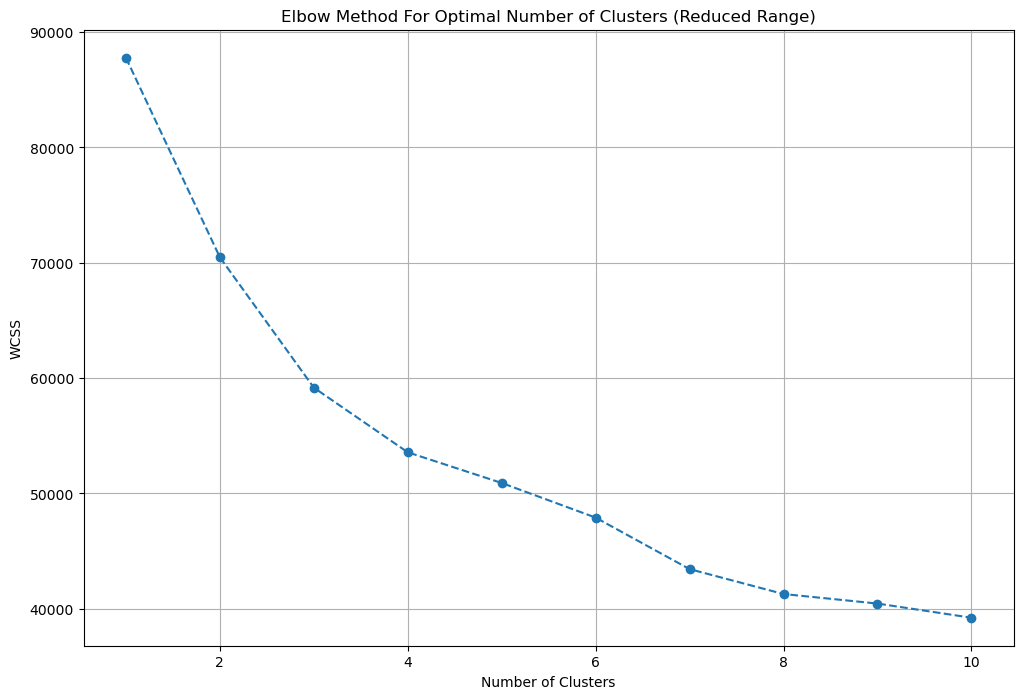

In [72]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Silhouette Score for k=2: 0.2834
Silhouette Score for k=3: 0.2088
Silhouette Score for k=4: 0.1981
Silhouette Score for k=5: 0.1816
Silhouette Score for k=6: 0.1867
Silhouette Score for k=7: 0.1971
Silhouette Score for k=8: 0.1978
Silhouette Score for k=9: 0.2000


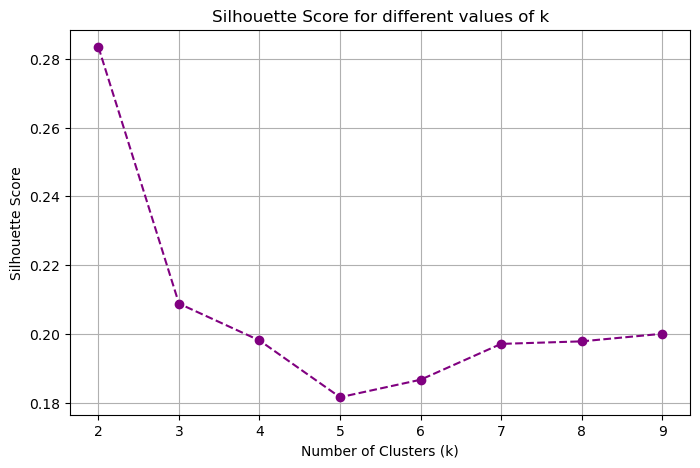

In [73]:
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_known)
    score = silhouette_score(scaled_known, cluster_labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for k={k}: {score:.4f}")

# Plotting the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='purple')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for different values of k")
plt.grid(True)
plt.show()


In [74]:
# Step : 7 Fitting the K-Means with 3 clusters
n_clusters = 3

# Fit the KMeans model

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_known)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_known)
known_df['furnish_cluster'] = cluster_assignments
known_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,Dining Table,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,furnish_cluster
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,1,0,0,1,0,0,1,2
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0,0,0,0,0,0,0,0,0,1
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0,1,0,0,0,0,0,0,0,1
5,"3 BHK Flat in Sector 102, Gurgaon",shapoorji pallonji joyville gurugram,2.65,14308,"1,852 sqft (172 sqm) Super Built-up Area",S83873914,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,3,...,0,1,0,0,0,0,0,0,0,1
6,2 BHK Independent Builder Floor in Sector-33 S...,Central Park Flower Valley Cerise Floors,1.75,13944,"1,255 sqft (117 sqm) Carpet Area",T83786356,https://www.99acres.com/2-bhk-bedroom-independ...,2,2,3+,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0,0,1,0,0,0,0,0,0,1
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,0,1,1,0,0,1,0,0,1,2
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,0,1,1,0,0,0,0,0,0,2
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,1,0,0,1,0,0,0,2


In [75]:
cluster_centroids = pd.DataFrame(kmeans.cluster_centers_, columns=furnishing_items)
cluster_centroids

,Fan,Exhaust Fan,Geyser,Light,Chimney,Wardrobe,AC,Bed,Curtains,Dining Table,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier
0,0.401575,0.430877,0.616791,0.156519,0.432721,0.550155,0.685030,1.407447,0.845382,1.957419,0.313419,1.271226,2.525968,2.121267,0.986607,1.409350,2.590244,1.346855
1,-0.394117,-0.388467,-0.525252,-0.387963,-0.374307,-0.432368,-0.435652,-0.156238,-0.273601,-0.255634,-0.312395,-0.507390,-0.328395,-0.236060,-0.605409,-0.159641,-0.298784,-0.501069
2,0.509975,0.492476,0.655946,0.571406,0.469425,0.527618,0.493645,-0.160585,0.189372,-0.162365,0.405649,0.437360,-0.211894,-0.241104,0.675930,-0.155727,-0.277658,0.405330


In [76]:
# Step 8: Analyze cluster centroids

cluster_centroids['total_items'] = cluster_centroids.sum(axis=1)
cluster_centroids.index.name = "cluster_id"
cluster_centroids

,Fan,Exhaust Fan,Geyser,Light,Chimney,Wardrobe,AC,Bed,Curtains,Dining Table,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,total_items
cluster_id,,,,,,,,,,,,,,,,,,,
0,0.401575,0.430877,0.616791,0.156519,0.432721,0.550155,0.685030,1.407447,0.845382,1.957419,0.313419,1.271226,2.525968,2.121267,0.986607,1.409350,2.590244,1.346855,20.048852
1,-0.394117,-0.388467,-0.525252,-0.387963,-0.374307,-0.432368,-0.435652,-0.156238,-0.273601,-0.255634,-0.312395,-0.507390,-0.328395,-0.236060,-0.605409,-0.159641,-0.298784,-0.501069,-6.572743
2,0.509975,0.492476,0.655946,0.571406,0.469425,0.527618,0.493645,-0.160585,0.189372,-0.162365,0.405649,0.437360,-0.211894,-0.241104,0.675930,-0.155727,-0.277658,0.405330,4.624801


In [77]:
# Step 9: Label each cluster manually
# Sort by total furnishing items to classify
cluster_map = (
    cluster_centroids['total_items']
    .sort_values(ascending=False)
    .reset_index()
    .assign(furnishing_type=['Furnished', 'Semi-Furnished', 'Unfurnished'])
)

cluster_map


,cluster_id,total_items,furnishing_type
0,0,20.048852,Furnished
1,2,4.624801,Semi-Furnished
2,1,-6.572743,Unfurnished


In [78]:
# Merge cluster labels with known_df
known_df = known_df.merge(cluster_map[['cluster_id', 'furnishing_type']],
                          left_on='furnish_cluster',
                          right_on='cluster_id',
                          how='left')

In [79]:

# Step 9: Assign "No Info" label to unknown
unknown_df['furnishing_type'] = 'No Info'

In [80]:
# Step 10: Combine both known and unknown
combined_df = pd.concat([known_df, unknown_df], axis=0, sort=False).sort_index()


In [81]:
combined_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,furnish_cluster,cluster_id,furnishing_type
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,Semi-Furnished
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Unfurnished
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Unfurnished
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info
3,"3 BHK Flat in Sector 102, Gurgaon",shapoorji pallonji joyville gurugram,2.65,14308,"1,852 sqft (172 sqm) Super Built-up Area",S83873914,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5940,"4 BHK Flat in Sector 69, Gurgaon",tulip purple,2.75,11458,"2,400 sqft (223 sqm) Super Built-up Area",N82695348,https://www.99acres.com/4-bhk-bedroom-apartmen...,4,5,3+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info
5950,"3 Bedroom House in Maruti Kunj, Gurgaon","Maruti Kunj, Gurgaon",0.42,8571,490 sqft (45.52 sqm) Plot Area,T83068078,https://www.99acres.com/3-bhk-bedroom-independ...,3,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info
5954,"2 BHK Flat in Sector 70A, Gurgaon",pyramid urban homes,0.70,7142,980 sqft (91 sqm) Carpet Area,X83066970,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info
5955,"3 BHK Independent Builder Floor in Sector 89, ...",M3M Soulitude,1.64,11010,"1,494 sqft (139 sqm) Carpet Area",L84504686,https://www.99acres.com/3-bhk-bedroom-independ...,3,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info


In [82]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,built_up_area,carpet_area,plot_area,total_area_sqft,study_room,servant_room,store_room,pooja_room,others,age_possession_category
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0.0,0.0,0.0,2701.0,0,1,0,0,1,New Property
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,1800.0,0.0,0.0,1800.0,0,0,0,0,0,Undefined
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0.0,0.0,4500.0,4500.0,0,1,0,0,0,Relatively New
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,0.0,0.0,0.0,1370.0,0,0,0,0,0,Old Property
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,0.0,0.0,1044.0,1044.0,0,0,0,0,0,Relatively New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0.0,0.0,1449.0,1449.0,0,0,0,1,0,Old Property
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,0.0,5500.0,0.0,5500.0,1,1,1,1,0,Relatively New
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,0.0,3800.0,0.0,3800.0,1,1,0,1,1,New Property
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0.0,0.0,0.0,2430.0,0,1,0,1,1,Relatively New


In [83]:
fe_df = fe_df.merge(
    combined_df[['property_id', 'furnishing_type']],
    on='property_id',
    how='left'
)


In [84]:
fe_df.shape

(5974, 32)

In [85]:
combined_df.groupby('furnishing_type').mean(numeric_only=True)

,price_in_cr,price_per_sqft,bedrooms,bathrooms,super_built_up_area,built_up_area,carpet_area,plot_area,total_area_sqft,study_room,...,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,furnish_cluster,cluster_id
furnishing_type,,,,,,,,,,,,,,,,,,,,,
Furnished,7.718028,37822.514228,5.445122,5.735772,1062.054878,439.091463,682.967480,1254.109756,2993.439024,0.447154,...,0.939024,0.849593,0.939024,0.640244,0.839431,2.668699,0.880081,0.878049,0.0,0.0
No Info,3.984704,22384.058341,3.784868,3.637192,826.989973,288.028259,238.005469,886.038286,2061.658159,0.207840,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Semi-Furnished,6.993777,25261.834221,4.294849,4.651273,1174.779159,517.546477,782.143872,972.004737,3006.808171,0.357608,...,0.974541,0.476613,0.050918,0.012433,0.691533,0.062759,0.017170,0.457667,2.0,2.0
Unfurnished,4.408283,22519.371662,3.804525,3.886869,1056.465134,351.578635,317.312315,709.525964,2230.376113,0.228487,...,0.698071,0.051558,0.012982,0.013724,0.073071,0.056009,0.010757,0.052300,1.0,1.0


In [86]:
combined_df.groupby('furnishing_type').mean(numeric_only=True)

,price_in_cr,price_per_sqft,bedrooms,bathrooms,super_built_up_area,built_up_area,carpet_area,plot_area,total_area_sqft,study_room,...,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,furnish_cluster,cluster_id
furnishing_type,,,,,,,,,,,,,,,,,,,,,
Furnished,7.718028,37822.514228,5.445122,5.735772,1062.054878,439.091463,682.967480,1254.109756,2993.439024,0.447154,...,0.939024,0.849593,0.939024,0.640244,0.839431,2.668699,0.880081,0.878049,0.0,0.0
No Info,3.984704,22384.058341,3.784868,3.637192,826.989973,288.028259,238.005469,886.038286,2061.658159,0.207840,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Semi-Furnished,6.993777,25261.834221,4.294849,4.651273,1174.779159,517.546477,782.143872,972.004737,3006.808171,0.357608,...,0.974541,0.476613,0.050918,0.012433,0.691533,0.062759,0.017170,0.457667,2.0,2.0
Unfurnished,4.408283,22519.371662,3.804525,3.886869,1056.465134,351.578635,317.312315,709.525964,2230.376113,0.228487,...,0.698071,0.051558,0.012982,0.013724,0.073071,0.056009,0.010757,0.052300,1.0,1.0


In [87]:
fe_df.isnull().sum()

property_name                0
society                      0
price_in_cr                  0
price_per_sqft               0
areawithtype                 0
property_id                  0
link                         0
bedrooms                     0
bathrooms                    0
balcony                      0
additional_room              0
floor_info                 104
facing                       0
property_age               110
furnishing_details         822
features                   376
nearby_location              0
property_type                0
sector                       0
floornum                   105
super_built_up_area          0
built_up_area                0
carpet_area                  0
plot_area                    0
total_area_sqft              0
study_room                   0
servant_room                 0
store_room                   0
pooja_room                   0
others                       0
age_possession_category      0
furnishing_type              0
dtype: i

#### 8. Features

In [88]:
fe_df['features'].unique()

array(["['Feng Shui / Vaastu Compliant', 'Water purifier', 'Lift(s)', 'High Ceiling Height', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']",
       nan,
       "['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community C

In [89]:
fe_df['features'].isnull().sum()

376

In [90]:
fe_df['features'].str.strip("[]").str.split("', '")

0       ['Feng Shui / Vaastu Compliant, Water purifier...
1                                                     NaN
2       ['Water purifier, Centrally Air Conditioned, S...
3       ['Feng Shui / Vaastu Compliant, Intercom Facil...
4                                       ['Water Storage']
                              ...                        
5969    ['Water Storage, Recently Renovated, Natural L...
5970    ['Security / Fire Alarm, Feng Shui / Vaastu Co...
5971    ['Water purifier, Centrally Air Conditioned, S...
5972    ['Water purifier, Centrally Air Conditioned, S...
5973    ['Security / Fire Alarm, Feng Shui / Vaastu Co...
Name: features, Length: 5974, dtype: object

In [91]:
fe_df['features'].unique()

array(["['Feng Shui / Vaastu Compliant', 'Water purifier', 'Lift(s)', 'High Ceiling Height', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']",
       nan,
       "['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community C

In [ ]:


# Step 1 : Binary Encoding

fe_df['features_list'] = fe_df['features'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)


# Initialize the binarizer
mlb = MultiLabelBinarizer()

# Fit and transform the feature lists
binary_features = mlb.fit_transform(fe_df['features_list'])

# Convert to DataFrame 
features_encoded = pd.DataFrame(
    binary_features,
    columns=mlb.classes_,  # Column names = unique features
    index=fe_df.index      # Preserve original DataFrame index
)

In [93]:
features_encoded

,Airy Rooms,Bank Attached Property,Centrally Air Conditioned,Club house / Community Center,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fitness Centre / GYM,High Ceiling Height,Intercom Facility,Internet/wi-fi connectivity,...,Security Personnel,Separate entry for servant room,Shopping Centre,Spacious Interiors,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier,Water softening plant
0,1,1,0,0,1,1,0,1,0,0,...,0,1,0,1,0,1,1,1,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,0,1,...,1,1,0,1,1,1,1,1,1,0
3,0,0,0,1,0,1,1,0,1,1,...,1,0,1,0,1,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
5970,1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,0,1,1,1,1,0
5971,1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,0
5972,1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,0


In [94]:
# Step 2 : Concatenate Encoded Features to Original Data

df_features = pd.concat([fe_df, features_encoded], axis=1)
df_features

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,Security Personnel,Separate entry for servant room,Shopping Centre,Spacious Interiors,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier,Water softening plant
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,0,1,0,1,1,1,1,0
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0,0,0,0,0,0,0,0,0,0
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,1,1,0,1,1,1,1,1,1,0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,1,0,1,0,1,0,0,0,0,1
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0,0,0,0,0,0,1,1,0,0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,1,1,0,1,0,1,1,1,1,0
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,1,1,0,1,1,1,1,1,1,0
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1,1,0,1,1,1,1,1,1,0


In [95]:
# Step 3 :  Compute Feature Rarity-Based Weights

# Count how many properties have each feature
feature_counts = features_encoded.sum()

# Rarity = inverse frequency (less common = higher weight)
feature_weights = 1 / feature_counts


In [96]:
# Step 4 : Compute Raw Luxury Score

# Multiply binary matrix by weights and sum across features
df_features['luxury_score'] = features_encoded.mul(feature_weights, axis=1).sum(axis=1)


In [97]:
df_features

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,Separate entry for servant room,Shopping Centre,Spacious Interiors,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier,Water softening plant,luxury_score
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1,0,1,0,1,1,1,1,0,0.005937
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0,0,0,0,0,0,0,0,0,0.000000
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,1,0,1,1,1,1,1,1,0,0.009914
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,0,1,0,1,0,0,0,0,1,0.004564
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,0,0,0,0,0,0,1,0,0,0.000229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0,0,0,0,0,1,1,0,0,0.002049
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,1,0,1,0,1,1,1,1,0,0.008534
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,1,0,1,1,1,1,1,1,0,0.010612
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1,0,1,1,1,1,1,1,0,0.010612


In [98]:

# Step 5 : Normalizing the Score 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_features['luxury_score_norm'] = scaler.fit_transform(df_features[['luxury_score']])


In [99]:



# Step 1 : Binary Encoding
fe_df['features_list'] = fe_df['features'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

# Initialize the binarizer
mlb = MultiLabelBinarizer()

# Fit and transform the feature lists
binary_features = mlb.fit_transform(fe_df['features_list'])

# Convert to DataFrame (optional)
features_encoded = pd.DataFrame(
    binary_features,
    columns=mlb.classes_,
    index=fe_df.index  # Preserve original DataFrame index
)

# Step 2 : Compute Feature Rarity-Based Weights
feature_counts = features_encoded.sum()
feature_weights = 1 / feature_counts  # Inverse frequency

# Step 3 : Compute Raw Luxury Score
fe_df['luxury_score'] = features_encoded.mul(feature_weights, axis=1).sum(axis=1)

# Step 4 : Normalize the Score
scaler = MinMaxScaler()
fe_df['luxury_score_norm'] = scaler.fit_transform(fe_df[['luxury_score']])


In [100]:
df_features[['features','luxury_score_norm']].sort_values(by='luxury_score_norm',ascending= False)

,features,luxury_score_norm
3903,"['Centrally Air Conditioned', 'Water purifier'...",1.0
974,"['Centrally Air Conditioned', 'Water purifier'...",1.0
1939,"['Centrally Air Conditioned', 'Water purifier'...",1.0
223,"['Centrally Air Conditioned', 'Water purifier'...",1.0
4694,"['Water purifier', 'Centrally Air Conditioned'...",1.0
...,...,...
632,NaN,0.0
5113,NaN,0.0
629,NaN,0.0
622,NaN,0.0


In [101]:
df_features[['features','luxury_score_norm']].sort_values(by='luxury_score_norm',ascending= False).tail(5)

,features,luxury_score_norm
632,NaN,0.0
5113,NaN,0.0
629,NaN,0.0
622,NaN,0.0
758,NaN,0.0


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


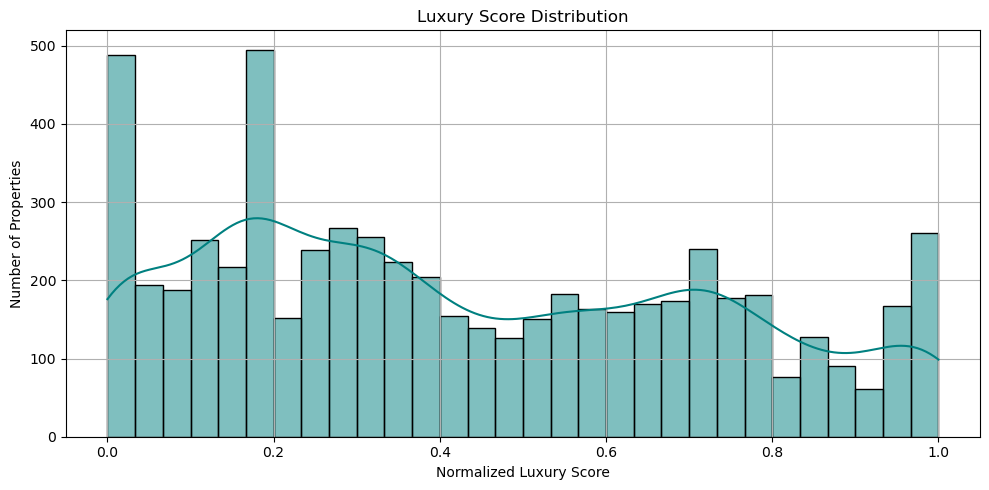

In [102]:

plt.figure(figsize=(10, 5))
sns.histplot(df_features['luxury_score_norm'], bins=30, kde=True, color='teal')
plt.title('Luxury Score Distribution')
plt.xlabel('Normalized Luxury Score')
plt.ylabel('Number of Properties')
plt.grid(True)
plt.tight_layout()
plt.show()


In [103]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,study_room,servant_room,store_room,pooja_room,others,age_possession_category,furnishing_type,features_list,luxury_score,luxury_score_norm
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,0,0,1,New Property,Semi-Furnished,"[Feng Shui / Vaastu Compliant, Water purifier,...",0.005937,0.472668
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0,0,0,0,0,Undefined,Unfurnished,[],0.000000,0.000000
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0,1,0,0,0,Relatively New,Unfurnished,"[Water purifier, Centrally Air Conditioned, Se...",0.009914,0.789272
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,0,0,0,0,0,Old Property,No Info,"[Feng Shui / Vaastu Compliant, Intercom Facili...",0.004564,0.363338
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,0,0,0,0,0,Relatively New,No Info,[Water Storage],0.000229,0.018251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0,0,0,1,0,Old Property,Unfurnished,"[Water Storage, Recently Renovated, Natural Li...",0.002049,0.163115
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,1,1,1,1,0,Relatively New,Semi-Furnished,"[Security / Fire Alarm, Feng Shui / Vaastu Com...",0.008534,0.679409
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,1,1,0,1,1,New Property,Semi-Furnished,"[Water purifier, Centrally Air Conditioned, Se...",0.010612,0.844880
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,0,1,1,Relatively New,Semi-Furnished,"[Water purifier, Centrally Air Conditioned, Se...",0.010612,0.844880


In [104]:
fe_df.shape

(5974, 35)

In [105]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,study_room,servant_room,store_room,pooja_room,others,age_possession_category,furnishing_type,features_list,luxury_score,luxury_score_norm
0,4 BHK Independent Builder Floor in Sushant Lok...,"Sushant Lok Phase 1, Gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,0,0,1,New Property,Semi-Furnished,"[Feng Shui / Vaastu Compliant, Water purifier,...",0.005937,0.472668
1,"5 Bedroom House in Sohna Road, Gurgaon","Sohna Road, Gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,0,0,0,0,0,Undefined,Unfurnished,[],0.000000,0.000000
2,"4 Bedroom House in Sector 72, Gurgaon",Tata Primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,0,1,0,0,0,Relatively New,Unfurnished,"[Water purifier, Centrally Air Conditioned, Se...",0.009914,0.789272
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,0,0,0,0,0,Old Property,No Info,"[Feng Shui / Vaastu Compliant, Intercom Facili...",0.004564,0.363338
4,"3 Bedroom House in Behrampur, Gurgaon","Behrampur, Gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,0,0,0,0,0,Relatively New,No Info,[Water Storage],0.000229,0.018251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","Sector 46, Gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,0,0,0,1,0,Old Property,Unfurnished,"[Water Storage, Recently Renovated, Natural Li...",0.002049,0.163115
5970,5 BHK Independent Builder Floor in DLF Phase 1...,DLF Phase 1 Ultra Luxury Builder Floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,1,1,1,1,0,Relatively New,Semi-Furnished,"[Security / Fire Alarm, Feng Shui / Vaastu Com...",0.008534,0.679409
5971,4 BHK Independent Builder Floor in DLF Phase 2...,DLF Luxury Builder Floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,1,1,0,1,1,New Property,Semi-Furnished,"[Water purifier, Centrally Air Conditioned, Se...",0.010612,0.844880
5972,"4 BHK Independent Builder Floor in Sector 67, ...",Ansal API Esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,0,1,0,1,1,Relatively New,Semi-Furnished,"[Water purifier, Centrally Air Conditioned, Se...",0.010612,0.844880


In [107]:
fe_df.to_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\latlong\wordcloud.csv",index= False)